In [1]:
import pandas as pd
import numpy as np
import torch
from deepod.models.time_series import TcnED
from utils.data_loader import load_volvo, load_optuna_val
from utils.hyperparameter_search import run_optuna_study

from utils.evaluation_hai import cross_validate_hai
from utils.data_loader_hai import load_hai_train
from utils.hyperparameter_search_hai import run_optuna_study_hai
from utils.evaluation import evaluate_model

result_path="../Results/HAI TcnED"

D:\Programming things\Examensarbete\Examensarbete 2.0\Exjobb-Gitrepo\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(torch.cuda.is_available())

True


### Optuna HPO

In [3]:
hyperparameters = {
    "lr": ("categorical", [1e-6, 1e-8, 1e-10]),
    "epochs": ("int", 5, 20, False),
    "rep_dim": ("int", 16, 64, False),
}

study = run_optuna_study_hai(
    model_class=TcnED,
    hyperparameters=hyperparameters,
    n_trials=10,
    study_name="Final_TcnED_hai_test_optuna_study", #
    storage="sqlite:///Final_TcnED_hai_optuna.db"
)

print("Best params:", study.best_params)
print("Best validation score:", study.best_value)
print("Best trial extra metrics:", study.best_trial.user_attrs)

Best params: {'lr': 1e-06, 'epochs': 14, 'rep_dim': 18}
Best validation score: 0.2821894463481735
Best trial extra metrics: {'pr_auc': 0.2821894463481735}


In [4]:
best_params = study.best_params
static_params = {
    "seq_len": 50,
    "stride": 5,
    "device": 'cuda'
}

params = best_params | static_params

### Training w. hpo parameters

In [5]:
X_train, X_test, y_test = load_hai_train()

model = TcnED(**params)

model.fit(X_train)

scores_test = model.decision_function(X_test)

### Threshold calculation

In [6]:
cross_val_scores = cross_validate_hai(model=TcnED, params=params, result_path=result_path)
print(cross_val_scores)

{'fold1_roc_auc': 0.48058682365307537, 'fold1_pr_auc': 0.28219131176337886, 'fold2_roc_auc': 0.5127221411250084, 'fold2_pr_auc': 0.03352002879576565, 'fold3_roc_auc': 0.49596346773523325, 'fold3_pr_auc': 0.2822598715679118, 'fold4_roc_auc': 0.5270504695545203, 'fold4_pr_auc': 0.050328030434202455, 'mean_threshold': 146.9790023803711}


### F1 calculation / evaluation of model

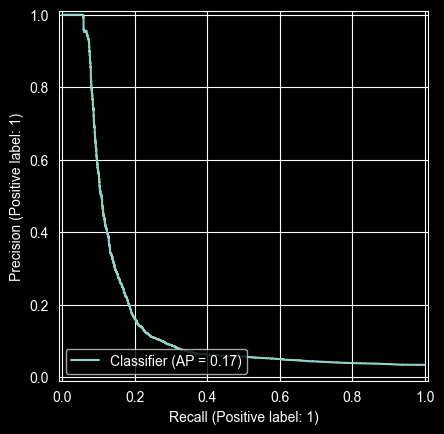

In [7]:
threshold = cross_val_scores["mean_threshold"]
evaluate_model(y_test, scores_test, threshold=threshold, result_path=result_path)

In [8]:
import pandas as pd
import os
df = pd.DataFrame(scores_test, columns=["score"])
scores_path = os.path.join(result_path, "scores.csv")
df.to_csv(scores_path, index = False)